In [6]:
import os
import math
from typing import Dict, Sequence, Optional, Tuple, Any, List

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from pcmdi_mov_reader import (
    ModeFileSpec,
    EMOVDiagReader,
)

In [7]:
class ExtrapropicalModeMapPlotter:
    """
    Plotter for PMP extratropical modes:

    1) Multi-product grid figures:
       - plot_mode_season_maps(...)

    2) Multi-panel "Obs + all models" with corr/RMSE annotations:
       - plot_multimodel_mode_pattern_with_stats(...)      # regional (mode bounds)
       - plot_multimodel_teleconnection_with_stats(...)    # global
    """

    def __init__(
        self,
        fig_dir: str,
        plot_dict: Dict[str, dict],
        group_order: Sequence[str] = ("hist", "future"),
        obs_key: str = "reference",
        lat_name: str = "latitude",
        lon_name: str = "longitude_a",
    ):
        self.fig_dir = fig_dir
        self.plot_dict = plot_dict
        self.group_order = tuple(group_order)
        self.obs_key = obs_key
        self.lat_name = lat_name
        self.lon_name = lon_name
        os.makedirs(self.fig_dir, exist_ok=True)

    # ==========================================================
    # Region helpers
    # ==========================================================
    def _normalize_lon_for_bounds(
        self,
        da: xr.DataArray,
        lon_convention: str,
    ) -> xr.DataArray:
        """
        Normalize lon coordinate to a convention and sort to monotonic.
        - "negpos": [-180, 180)
        - "0_360": [0, 360)
        """
        lon = da[self.lon_name]
        if lon_convention == "negpos":
            lon2 = ((lon + 180.0) % 360.0) - 180.0
            da = da.assign_coords({self.lon_name: lon2}).sortby(self.lon_name)
        elif lon_convention == "0_360":
            lon2 = lon % 360.0
            da = da.assign_coords({self.lon_name: lon2}).sortby(self.lon_name)
        else:
            raise ValueError(f"Unknown lon_convention={lon_convention!r}")
        return da

    def _subset_latlon(
        self,
        da: xr.DataArray,
        lat_bnds: Optional[Tuple[float, float]],
        lon_bnds: Optional[Tuple[float, float]],
        lon_convention: str,
    ) -> xr.DataArray:
        """
        Subset da on lat/lon bounds with wrap handling.
        IMPORTANT: For negative/positive lon bounds (e.g., -80..40),
        use lon_convention="negpos".
        """
        da2 = da

        if lon_bnds is not None:
            da2 = self._normalize_lon_for_bounds(da2, lon_convention)

        if lat_bnds is not None:
            la0, la1 = lat_bnds
            lo, hi = (la0, la1) if la0 <= la1 else (la1, la0)
            da2 = da2.sel({self.lat_name: slice(lo, hi)})

        if lon_bnds is not None:
            lo0, lo1 = lon_bnds

            if lo0 <= lo1:
                da2 = da2.sel({self.lon_name: slice(lo0, lo1)})
            else:
                if lon_convention == "negpos":
                    a = da2.sel({self.lon_name: slice(lo0, 180)})
                    b = da2.sel({self.lon_name: slice(-180, lo1)})
                    da2 = xr.concat([a, b], dim=self.lon_name)
                else:
                    a = da2.sel({self.lon_name: slice(lo0, 360)})
                    b = da2.sel({self.lon_name: slice(0, lo1)})
                    b = b.assign_coords({self.lon_name: b[self.lon_name] + 360.0})
                    da2 = xr.concat([a, b], dim=self.lon_name)

        if da2.sizes.get(self.lat_name, 0) == 0 or da2.sizes.get(self.lon_name, 0) == 0:
            raise ValueError("Region bounds produced empty lat/lon selection.")

        return da2

    # ==========================================================
    # Stats helper
    # ==========================================================
    @staticmethod
    def _weighted_corr_rmse(
        obs2d: np.ndarray,
        mod2d: np.ndarray,
        w2d: Optional[np.ndarray] = None,
    ) -> Tuple[float, float]:
        """Return (corr, rmse) between two 2D arrays with optional weights."""
        m = np.isfinite(obs2d) & np.isfinite(mod2d)
        if not np.any(m):
            return np.nan, np.nan

        x = obs2d[m].astype(float)
        y = mod2d[m].astype(float)

        if w2d is None:
            x0 = x - x.mean()
            y0 = y - y.mean()
            denom = np.sqrt((x0 * x0).mean()) * np.sqrt((y0 * y0).mean())
            corr = np.nan if denom == 0 else float((x0 * y0).mean() / denom)
            rmse = float(np.sqrt(((y - x) ** 2).mean()))
            return corr, rmse

        w = w2d[m].astype(float)
        wsum = np.sum(w)
        if wsum == 0:
            return np.nan, np.nan
        w = w / wsum

        mx = np.sum(w * x)
        my = np.sum(w * y)
        x0 = x - mx
        y0 = y - my
        cov = np.sum(w * x0 * y0)
        sx = np.sqrt(np.sum(w * x0 * x0))
        sy = np.sqrt(np.sum(w * y0 * y0))
        corr = np.nan if (sx == 0 or sy == 0) else float(cov / (sx * sy))
        rmse = float(np.sqrt(np.sum(w * (y - x) ** 2)))
        return corr, rmse

    # ==========================================================
    # Existing multi-row plot API
    # ==========================================================
    def _panel_label(self, key: str) -> str:
        style = self.plot_dict.get(key, {})
        return style.get("label", key)

    def _build_mean_maps(self, data_dict: Dict[str, xr.DataArray]) -> Dict[str, xr.DataArray]:
        if self.obs_key not in data_dict:
            raise ValueError(f"data_dict must contain obs_key='{self.obs_key}'")

        mean_maps: Dict[str, xr.DataArray] = {}

        ref = data_dict[self.obs_key]
        extra_dims = [d for d in ref.dims if d not in (self.lat_name, self.lon_name)]
        if extra_dims:
            ref = ref.mean(dim=extra_dims)
        mean_maps[self.obs_key] = ref

        for key in self.group_order:
            if key not in data_dict:
                continue
            da = data_dict[key]
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if extra_dims:
                da = da.mean(dim=extra_dims)
            mean_maps[key] = da

        return mean_maps

    def _build_spread_maps(self, data_dict: Dict[str, xr.DataArray]) -> Dict[str, xr.DataArray]:
        spread_maps: Dict[str, xr.DataArray] = {}
        for key in self.group_order:
            if key not in data_dict:
                continue
            da = data_dict[key]
            extra_dims = [d for d in da.dims if d not in (self.lat_name, self.lon_name)]
            if not extra_dims:
                continue
            spread_maps[key] = da.std(dim=extra_dims)
        return spread_maps

    @staticmethod
    def _auto_symmetric_levels(
        arrs: List[np.ndarray],
        nlevels: int = 17,
        vlim: Optional[float] = None,
    ) -> Tuple[np.ndarray, float, float]:
        vals = np.concatenate([a.ravel() for a in arrs])
        finite = np.isfinite(vals)
        if not np.any(finite):
            vmax = 1.0 if vlim is None else float(vlim)
        else:
            vmax = float(np.nanmax(np.abs(vals[finite]))) if vlim is None else float(vlim)
        vmin = -vmax
        levels = np.linspace(vmin, vmax, nlevels)
        return levels, vmin, vmax

    @staticmethod
    def _auto_spread_level_from_quantile(
        spreads: List[np.ndarray],
        quantile: float = 0.75,
    ) -> Optional[float]:
        if not spreads:
            return None
        vals = np.concatenate([s.ravel() for s in spreads])
        finite = np.isfinite(vals)
        if not np.any(finite):
            return None
        return float(np.nanpercentile(vals[finite], quantile * 100.0))

    def plot_mode_season_maps(
        self,
        *,
        mode: str,
        season: str,
        products: Dict[str, Dict[str, xr.DataArray]],
        product_order: Optional[Sequence[str]] = None,
        product_labels: Optional[Dict[str, str]] = None,
        filename: Optional[str] = None,
        cmap: str = "RdBu_r",
        central_lon: float = 180.0,
        figsize: Tuple[float, float] = (15, 9),
        fontz: int = 13,
        yticks: Optional[np.ndarray] = None,
        xtick_step: float = 30.0,
        extent: Optional[Tuple[float, float, float, float]] = None,
        mlevels_by_product: Optional[Dict[str, Sequence[float]]] = None,
        nlevels: int = 17,
        overlay_spread: bool = True,
        spread_quantile: float = 0.75,
        spread_level_by_product: Optional[Dict[str, float]] = None,
        hatch: str = "....",
        cb_labels_by_product: Optional[Dict[str, str]] = None,
        one_colorbar_per_row: bool = True,
        fig_format: str = "pdf",
        fig_dpi: int = 300,
        fig_idx_start: int = 0,
    ):
        if product_order is None:
            product_order = list(products.keys())
        else:
            product_order = list(product_order)

        if product_labels is None:
            product_labels = {}
        if cb_labels_by_product is None:
            cb_labels_by_product = {}
        if mlevels_by_product is None:
            mlevels_by_product = {}
        if spread_level_by_product is None:
            spread_level_by_product = {}

        panel_keys = [self.obs_key] + list(self.group_order)
        ncols = len(panel_keys)
        nrows = len(product_order)

        mean_maps_by_prod: Dict[str, Dict[str, xr.DataArray]] = {}
        spread_maps_by_prod: Dict[str, Dict[str, xr.DataArray]] = {}
        for pk in product_order:
            dd = products[pk]
            mean_maps_by_prod[pk] = self._build_mean_maps(dd)
            spread_maps_by_prod[pk] = self._build_spread_maps(dd)

        pk0 = product_order[0]
        ref0 = mean_maps_by_prod[pk0][self.obs_key]
        lat = ref0[self.lat_name].values
        lon = ref0[self.lon_name].values

        if yticks is None:
            yticks = np.arange(-90, 91, 30)
        xticks = np.arange(np.floor(lon.min()), np.ceil(lon.max()) + 1e-9, xtick_step)

        if extent is None:
            extent = (float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max()))

        fig = plt.figure(figsize=figsize)
        proj = ccrs.PlateCarree(central_longitude=central_lon)
        data_crs = ccrs.PlateCarree()

        axes: List[Any] = []
        ims: Dict[str, Any] = {}

        fig.suptitle(f"{mode} — {season}", fontsize=fontz * 1.25, y=0.98)

        left, right, bottom, top = 0.06, 0.98, 0.06, 0.93
        hspace, wspace = 0.12, 0.12

        if not one_colorbar_per_row:
            right = 0.92

        for r, pk in enumerate(product_order):
            mp = mean_maps_by_prod[pk]
            sp = spread_maps_by_prod[pk]

            if pk in mlevels_by_product and mlevels_by_product[pk] is not None:
                mlevels = np.asarray(list(mlevels_by_product[pk]), dtype=float)
                vmin, vmax = float(np.min(mlevels)), float(np.max(mlevels))
            else:
                arrs = [mp[k].values for k in panel_keys]
                mlevels, vmin, vmax = self._auto_symmetric_levels(arrs, nlevels=nlevels)

            spread_level = spread_level_by_product.get(pk, None)
            if overlay_spread and spread_level is None and sp:
                spread_arrays = [sp[k].values for k in self.group_order if k in sp]
                spread_level = self._auto_spread_level_from_quantile(
                    spread_arrays, quantile=spread_quantile
                )

            for c, key in enumerate(panel_keys):
                idx = r * ncols + c + 1
                ax = fig.add_subplot(nrows, ncols, idx, projection=proj)
                ax.set_aspect("auto")
                axes.append(ax)

                da_map = mp[key]

                im = ax.contourf(
                    lon, lat, da_map,
                    levels=mlevels,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    transform=data_crs,
                    extend="both",
                )
                ims[pk] = im

                ax.contour(
                    lon, lat, da_map,
                    levels=mlevels,
                    colors="k",
                    linewidths=0.3,
                    transform=data_crs,
                )

                ax.coastlines(linewidth=0.5)
                ax.set_extent(extent, crs=data_crs)

                ax.set_yticks(yticks, crs=data_crs)
                ax.set_xticks(xticks, crs=data_crs)
                ax.xaxis.set_major_formatter(LongitudeFormatter(".0f"))
                ax.yaxis.set_major_formatter(LatitudeFormatter(".0f"))

                if overlay_spread and (key in sp) and (spread_level is not None):
                    spread = sp[key].values
                    spread_mask = np.where(spread > spread_level, 1.0, np.nan)
                    ax.contourf(
                        lon, lat, spread_mask,
                        levels=[0.5, 1.5],
                        hatches=[hatch],
                        colors="none",
                        transform=data_crs,
                    )

                panel_lab = self._panel_label(key)
                panel_letter = chr(97 + (idx - 1 + fig_idx_start))
                ax.set_title(f"({panel_letter}) {panel_lab}", loc="left", fontsize=fontz)

                if c == ncols - 1:
                    row_label = product_labels.get(pk, pk)
                    ax.set_title(row_label, loc="right", fontsize=fontz)

                ax.tick_params(labelsize=fontz * 0.9)
                if c == 0:
                    ax.set_ylabel("Latitude", fontsize=fontz)
                ax.set_xlabel("Longitude", fontsize=fontz)

        fig.subplots_adjust(
            left=left, right=right, bottom=bottom, top=top, hspace=hspace, wspace=wspace
        )

        if one_colorbar_per_row:
            for r, pk in enumerate(product_order):
                im = ims[pk]
                row_height = (top - bottom - hspace * (nrows - 1)) / nrows
                row_bottom = top - (r + 1) * row_height - r * hspace
                cax_h = 0.018
                cax_y = row_bottom - 0.028
                cax = fig.add_axes([left, cax_y, right - left, cax_h])

                cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
                cbar.ax.tick_params(labelsize=fontz * 0.85)

                cb_lab = cb_labels_by_product.get(pk, "Map value")
                cbar.set_label(cb_lab, fontsize=fontz * 0.9)
        else:
            im_last = ims[product_order[-1]]
            cax = fig.add_axes([0.94, 0.15, 0.015, 0.70])
            cbar = fig.colorbar(im_last, cax=cax, orientation="vertical")
            cbar.ax.tick_params(labelsize=fontz * 0.85)
            cbar.set_label("Map value", fontsize=fontz * 0.9)

        if filename is None:
            filename = f"{mode}_{season}_mode_maps.{fig_format}"

        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(
            out_path,
            dpi=fig_dpi,
            format=fig_format,
            bbox_inches="tight",
            pad_inches=0.05,
        )
        print(f"Saved: {out_path}")

        return fig, axes

    # ==========================================================
    # Multimodel panel plot (regional OR global)
    # ==========================================================
    def plot_multimodel_teleconnection_with_stats(
        self,
        *,
        mode: str,
        token: str,
        obs_map: xr.DataArray,
        model_stack: xr.DataArray,
        member_labels: Sequence[str],
        filename: str,
        central_lon: float = 180.0,
        lon_convention: str = "0_360",
        cbar_label: str = "Teleconnection slope (units as provided)",
        **kwargs,
    ):
        return self.plot_multimodel_panel_with_stats(
            title=f"{mode} teleconnection — {token}",
            obs_map=obs_map,
            model_stack=model_stack,
            member_labels=member_labels,
            filename=filename,
            region_lat_bounds=None,
            region_lon_bounds=None,
            lon_convention=lon_convention,
            central_lon=central_lon,
            cbar_label=cbar_label,
            **kwargs,
        )
    def plot_multimodel_panel_with_stats(
        self,
        *,
        title: str,
        obs_map: xr.DataArray,
        model_stack: xr.DataArray,
        member_labels: Sequence[str],
        member_dim: str = "member",
        filename: str = "mode_multimodel.pdf",
        cmap: str = "RdBu_r",
        central_lon: float = 180.0,
        fontz: int = 12,
        fig_dpi: int = 300,
        fig_format: str = "pdf",
        area_weight: bool = True,
        region_lat_bounds: Optional[Tuple[float, float]] = None,
        region_lon_bounds: Optional[Tuple[float, float]] = None,
        lon_convention: str = "negpos",
        ncols: int = 2,
        figsize_per_panel: Tuple[float, float] = (5.0, 3.3),
        wspace: float = 0.10,
        hspace: float = 0.18,
        cb_pad: float = 0.08,
        xtick_step: float = 20.0,
        yticks: Optional[np.ndarray] = None,
        mlevels: Optional[Sequence[float]] = None,
        nlevels: int = 17,
        cbar_label: str = "EOF pattern (units as provided)",
        extent_override: Optional[Tuple[float, float, float, float]] = None,
    ):
        panels: List[Tuple[str, xr.DataArray]] = [("Obs", obs_map)]
        for i in range(model_stack.sizes[member_dim]):
            panels.append((member_labels[i], model_stack.isel({member_dim: i})))

        n_panels = len(panels)
        ncols = max(1, int(ncols))
        nrows = int(math.ceil(n_panels / ncols))
        panels_plot: List[Tuple[str, xr.DataArray]] = []
        if region_lat_bounds is None and region_lon_bounds is None:
            global_lon_convention = lon_convention
            obs0 = self._normalize_lon_for_bounds(obs_map, global_lon_convention)
            panels_plot.append(("Obs", obs0))
            for i in range(model_stack.sizes[member_dim]):
                da = model_stack.isel({member_dim: i})
                da = self._normalize_lon_for_bounds(da, global_lon_convention)
                panels_plot.append((member_labels[i], da))
        else:
            for name, da in panels:
                da_sub = self._subset_latlon(da, region_lat_bounds, region_lon_bounds, lon_convention)
                panels_plot.append((name, da_sub))

        obs_plot = panels_plot[0][1]
        lat_plot = obs_plot[self.lat_name].values
        lon_plot = obs_plot[self.lon_name].values

        if yticks is None:
            yticks = np.arange(
                np.floor(lat_plot.min() / 10) * 10,
                np.ceil(lat_plot.max() / 10) * 10 + 1e-9,
                10,
            )

        xticks = np.arange(
            np.floor(lon_plot.min() / xtick_step) * xtick_step,
            np.ceil(lon_plot.max() / xtick_step) * xtick_step + 1e-9,
            xtick_step,
        )

        if mlevels is None:
            all_vals = np.concatenate([da.values.ravel() for _, da in panels_plot])
            finite = np.isfinite(all_vals)
            vmax = float(np.nanmax(np.abs(all_vals[finite]))) if np.any(finite) else 1.0
            vmin = -vmax
            mlevels_arr = np.linspace(vmin, vmax, nlevels)
        else:
            mlevels_arr = np.asarray(list(mlevels), dtype=float)
            vmin, vmax = float(np.min(mlevels_arr)), float(np.max(mlevels_arr))

        if area_weight:
            w = np.cos(np.deg2rad(lat_plot)).astype(float)
            w = w / np.nanmean(w)
            w2d = w[:, None] * np.ones((lat_plot.size, lon_plot.size), dtype=float)
        else:
            w2d = None

        fig_w = figsize_per_panel[0] * ncols
        fig_h = figsize_per_panel[1] * nrows + 0.9
        fig = plt.figure(figsize=(fig_w, fig_h))

        proj = ccrs.PlateCarree(central_longitude=central_lon)
        data_crs = ccrs.PlateCarree()

        fig.suptitle(title, fontsize=fontz * 1.25, y=0.98)

        axes: List[Any] = []
        im_last = None

        if extent_override is not None:
            extent = extent_override
        else:
            extent = (
                float(lon_plot.min()),
                float(lon_plot.max()),
                float(lat_plot.min()),
                float(lat_plot.max()),
            )

        for p in range(n_panels):
            ax = fig.add_subplot(nrows, ncols, p + 1, projection=proj)
            axes.append(ax)

            name, da = panels_plot[p]

            im_last = ax.contourf(
                lon_plot,
                lat_plot,
                da.values,
                levels=mlevels_arr,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                transform=data_crs,
                extend="both",
            )
            ax.contour(
                lon_plot,
                lat_plot,
                da.values,
                levels=mlevels_arr,
                colors="k",
                linewidths=0.3,
                transform=data_crs,
            )

            ax.coastlines(linewidth=0.6)
            ax.set_extent(extent, crs=data_crs)

            ax.set_xticks(xticks, crs=data_crs)
            ax.set_yticks(yticks, crs=data_crs)
            ax.xaxis.set_major_formatter(LongitudeFormatter(".0f"))
            ax.yaxis.set_major_formatter(LatitudeFormatter(".0f"))
            ax.tick_params(labelsize=fontz * 0.85)

            letter = chr(97 + p)
            ax.set_title(f"({letter}) {name}", loc="left", fontsize=fontz)

            if p > 0:
                r0, rmse0 = self._weighted_corr_rmse(
                    panels_plot[0][1].values,
                    da.values,
                    w2d=w2d,
                )
                txt = f"r = {r0:.2f}\nRMSE = {rmse0:.2f}"
                ax.text(
                    0.98,
                    0.98,
                    txt,
                    transform=ax.transAxes,
                    ha="right",
                    va="top",
                    fontsize=fontz * 0.9,
                    bbox=dict(
                        facecolor="white",
                        edgecolor="0.7",
                        alpha=0.9,
                        boxstyle="round,pad=0.25",
                    ),
                )

            if (p % ncols) == 0:
                ax.set_ylabel("Latitude", fontsize=fontz)
            ax.set_xlabel("Longitude", fontsize=fontz)

        fig.subplots_adjust(
            left=0.06, right=0.98, top=0.92, bottom=0.12, wspace=wspace, hspace=hspace
        )

        cbar = fig.colorbar(
            im_last,
            ax=axes,
            orientation="horizontal",
            fraction=0.05,
            pad=cb_pad,
            aspect=45,
        )
        cbar.ax.tick_params(labelsize=fontz * 0.85)
        cbar.set_label(cbar_label, fontsize=fontz)

        out_path = os.path.join(self.fig_dir, filename)
        fig.savefig(
            out_path,
            dpi=fig_dpi,
            format=fig_format,
            bbox_inches="tight",
            pad_inches=0.05,
        )
        print(f"Saved: {out_path}")
        return fig, axes

    # ==========================================================
    # Convenience wrappers
    # ==========================================================
    def plot_multimodel_mode_pattern_with_stats(
        self,
        *,
        mode: str,
        token: str,
        obs_map: xr.DataArray,
        model_stack: xr.DataArray,
        member_labels: Sequence[str],
        filename: str,
        region_lat_bounds: Tuple[float, float],
        region_lon_bounds: Tuple[float, float],
        lon_convention: str = "negpos",
        central_lon: float = 0.0,
        cbar_label: str = "EOF pattern (units as provided)",
        **kwargs,
    ):
        return self.plot_multimodel_panel_with_stats(
            title=f"{mode} pattern — {token}",
            obs_map=obs_map,
            model_stack=model_stack,
            member_labels=member_labels,
            filename=filename,
            region_lat_bounds=region_lat_bounds,
            region_lon_bounds=region_lon_bounds,
            lon_convention=lon_convention,
            central_lon=central_lon,
            cbar_label=cbar_label,
            **kwargs,
        )

    def plot_multimodel_teleconnection_with_stats(
        self,
        *,
        mode: str,
        token: str,
        obs_map: xr.DataArray,
        model_stack: xr.DataArray,
        member_labels: Sequence[str],
        filename: str,
        central_lon: float = 180.0,
        cbar_label: str = "Teleconnection slope (units as provided)",
        **kwargs,
    ):
        return self.plot_multimodel_panel_with_stats(
            title=f"{mode} teleconnection — {token}",
            obs_map=obs_map,
            model_stack=model_stack,
            member_labels=member_labels,
            filename=filename,
            region_lat_bounds=None,
            region_lon_bounds=None,
            lon_convention="0_360",
            central_lon=central_lon,
            cbar_label=cbar_label,
            **kwargs,
        )

Saved: ./NAO_monthly_psl_eof1_MODE_PATTERN_region.pdf
Saved: ./NAO_monthly_psl_eof1_MODE_PATTERN_region.pdf
Saved: ./NAO_monthly_psl_eof1_TELECONNECTION_global.pdf
Saved: ./NAO_monthly_psl_eof1_TELECONNECTION_global.pdf


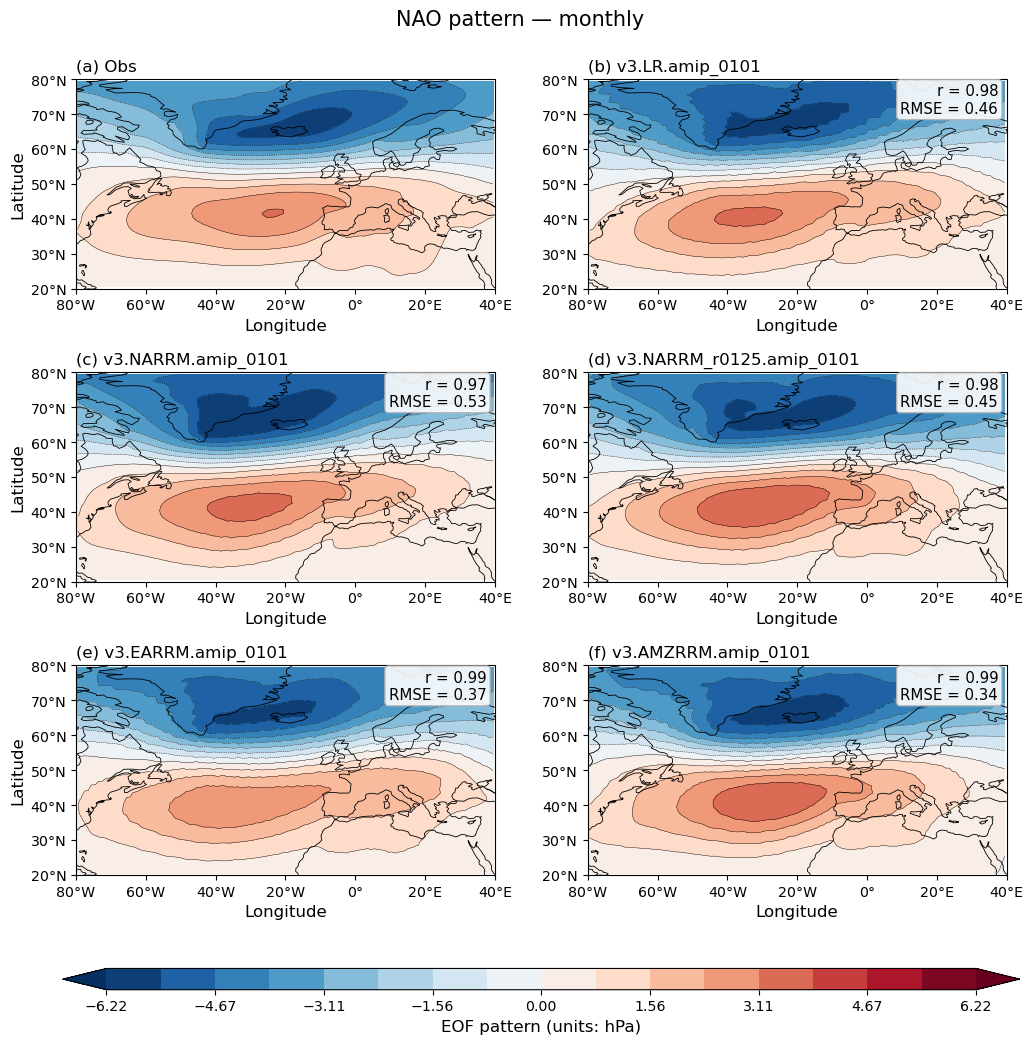

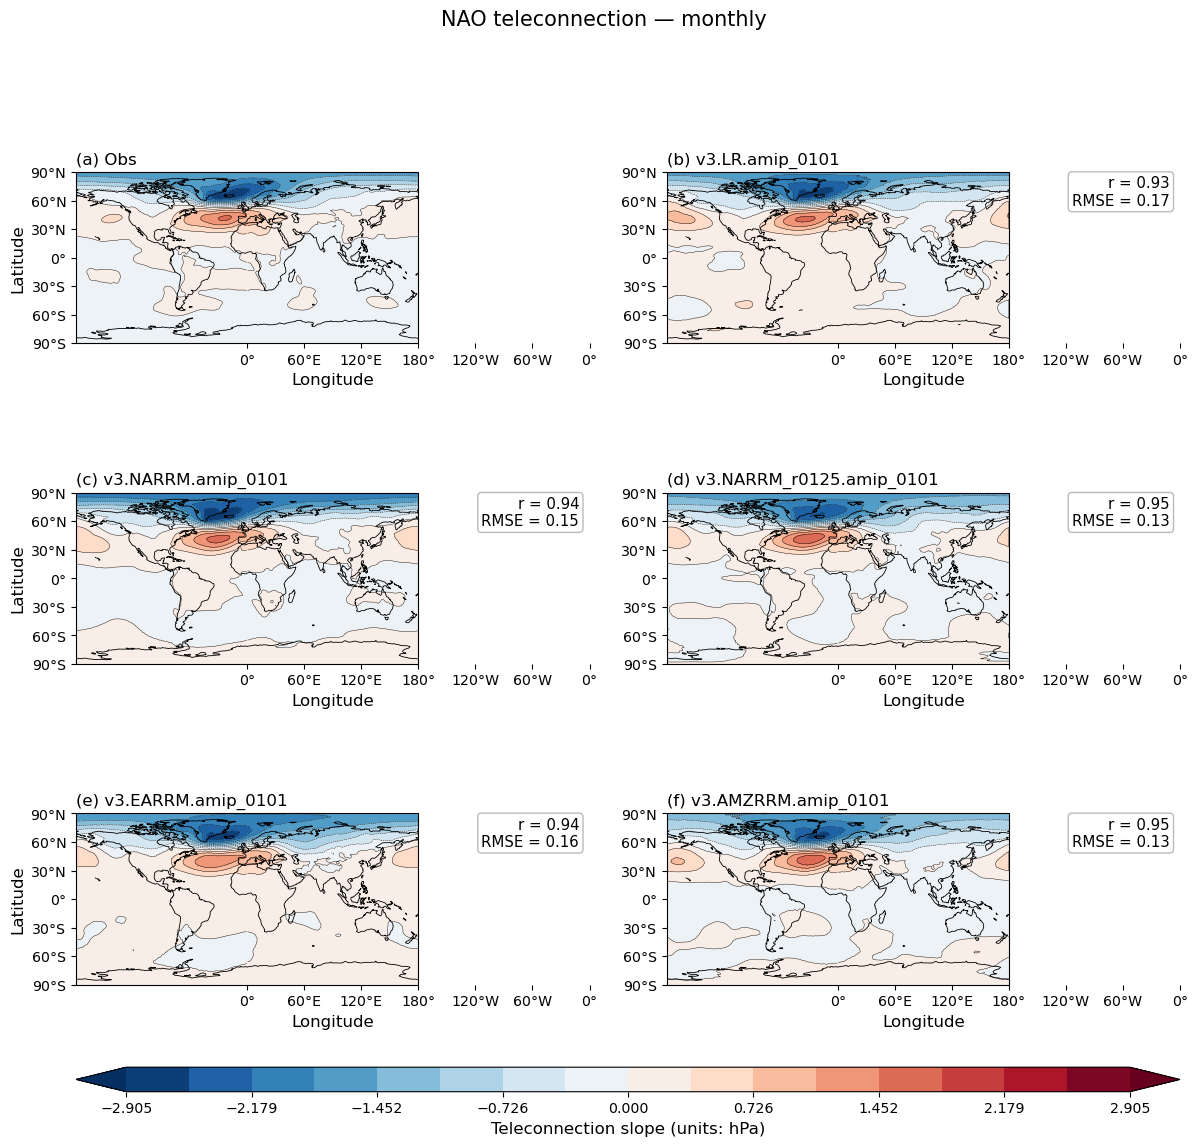

In [15]:

if __name__ == "__main__":
    TOP_DIR = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper"
    DATA_DIR = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi/overview_rrm"
    OUT_DIR = f"{TOP_DIR}/figure_data"
    FIG_DIR = "./"

    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    mode_dict = {
        "AMO":  {"eof": "eof1", "var": "ts",  "obs": "HadSST2",  "lat_bnds": (0, 70),    "lon_bnds": (-80, 0)},
        "PDO":  {"eof": "eof1", "var": "ts",  "obs": "HadSST2"},
        "NPGO": {"eof": "eof2", "var": "ts",  "obs": "HadSST2"},
        "NAM":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 90),   "lon_bnds": (-180, 180)},
        "NAO":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 80),   "lon_bnds": (-80, 40)},
        "NPO":  {"eof": "eof2", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 80),   "lon_bnds": (120, -120)},
        "PNA":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (20, 80),   "lon_bnds": (120, -60)},
        "SAM":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (-90, -20), "lon_bnds": (-180, 180)},
        "PSA1": {"eof": "eof2", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (-90, -20), "lon_bnds": (120, -60)},
        "PSA2": {"eof": "eof3", "var": "psl", "obs": "NOAA-20C", "lat_bnds": (-90, -20), "lon_bnds": (120, -60)},
    }

    MODEL = [
        "v3.LR.amip_0101",
        "v3.NARRM.amip_0101",
        "v3.NARRM_r0125.amip_0101",
        "v3.EARRM.amip_0101",
        "v3.AMZRRM.amip_0101",
    ]

    PERIOD = (1985, 2014)

    MODE_TO_PLOT = "NAO"
    TOKEN_TO_PLOT = "monthly"

    obs_dataset_map = {m: cfg["obs"] for m, cfg in mode_dict.items()}

    reader = EMOVDiagReader(
        data_dir=DATA_DIR,
        prefer_cbf=True,
        obs_key="obs",
        model_key="e3sm",
        target_lat_name="latitude",
        target_lon_name="longitude_a",
        obs_dataset_map=obs_dataset_map,
        normalize_lon_360=True,
        sort_latlon=True,
    )

    plotter = ExtrapropicalModeMapPlotter(
        fig_dir=FIG_DIR,
        plot_dict={"reference": {"label": "Obs"}, "hist": {"label": "E3SM"}},
        group_order=("hist",),
        obs_key="reference",
        lat_name="latitude",
        lon_name="longitude_a",
    )

    if MODE_TO_PLOT not in mode_dict:
        raise KeyError(
            f"MODE_TO_PLOT='{MODE_TO_PLOT}' not in mode_dict keys={list(mode_dict.keys())}"
        )

    cfg = mode_dict[MODE_TO_PLOT]
    var = cfg["var"]
    eof = cfg["eof"]
    lat_bnds = cfg.get("lat_bnds")
    lon_bnds = cfg.get("lon_bnds")

    if var == "psl":
        valid_tokens = {"DJF", "MAM", "JJA", "SON", "monthly", "yearly"}
    else:
        valid_tokens = {"monthly", "yearly"}

    if TOKEN_TO_PLOT not in valid_tokens:
        raise ValueError(
            f"Invalid TOKEN_TO_PLOT='{TOKEN_TO_PLOT}' for var='{var}'. "
            f"Valid={sorted(valid_tokens)}"
        )

    spec = ModeFileSpec(
        mode=MODE_TO_PLOT,
        var=var,
        eof=eof,
        period=PERIOD,
        season_or_freq=TOKEN_TO_PLOT,
    )

    _ = reader.obs_path(MODEL[0], spec)
    _ = reader.model_path(MODEL[0], spec)

    # ==========================================================
    # FIGURE 1: MODE PATTERN
    # ==========================================================
    dd_pat = reader.build_multimodel_stack(MODEL, spec, which="eof", member_dim="member")
    fname_pat = f"{MODE_TO_PLOT}_{TOKEN_TO_PLOT}_{var}_{eof}_MODE_PATTERN_region.pdf"

    if lat_bnds is not None and lon_bnds is not None:
        plotter.plot_multimodel_mode_pattern_with_stats(
            mode=MODE_TO_PLOT,
            token=TOKEN_TO_PLOT,
            obs_map=dd_pat["reference"],
            model_stack=dd_pat["hist"],
            member_labels=MODEL,
            filename=fname_pat,
            region_lat_bounds=lat_bnds,
            region_lon_bounds=lon_bnds,
            lon_convention="negpos",
            central_lon=0.0,
            ncols=2,
            figsize_per_panel=(5.2, 3.6),
            xtick_step=20.0,
            wspace=0.15,
            hspace=0.40,
            cb_pad=0.10,
            cbar_label="EOF pattern (units: hPa)" if var == "psl" else "EOF pattern (units as provided)",
        )
    else:
        plotter.plot_multimodel_panel_with_stats(
            title=f"{MODE_TO_PLOT} pattern — {TOKEN_TO_PLOT}",
            obs_map=dd_pat["reference"],
            model_stack=dd_pat["hist"],
            member_labels=MODEL,
            filename=fname_pat,
            region_lat_bounds=None,
            region_lon_bounds=None,
            lon_convention="0_360",
            central_lon=180.0,
            ncols=2,
            figsize_per_panel=(6.0, 4.0),
            xtick_step=60.0,
            yticks=np.arange(-90, 91, 30),
            wspace=0.15,
            hspace=0.25,
            cb_pad=0.08,
            cbar_label="EOF pattern (units as provided)",
        )
    print("Saved:", os.path.join(FIG_DIR, fname_pat))

    # ==========================================================
    # FIGURE 2: TELECONNECTION
    # ==========================================================
    dd_tel = reader.build_multimodel_stack(MODEL, spec, which="slope", member_dim="member")
    fname_tel = f"{MODE_TO_PLOT}_{TOKEN_TO_PLOT}_{var}_{eof}_TELECONNECTION_global.pdf"

    plotter.plot_multimodel_teleconnection_with_stats(
        mode=MODE_TO_PLOT,
        token=TOKEN_TO_PLOT,
        obs_map=dd_tel["reference"],
        model_stack=dd_tel["hist"],
        member_labels=MODEL,
        filename=fname_tel,
        central_lon=0.0,
        ncols=2,
        figsize_per_panel=(6.0, 4.0),
        xtick_step=60.0,
        yticks=np.arange(-90, 91, 30),
        wspace=0.15,
        hspace=0.25,
        cb_pad=0.08,
        cbar_label="Teleconnection slope (units: hPa)" if var == "psl" else "Teleconnection slope (units as provided)",
    )
    print("Saved:", os.path.join(FIG_DIR, fname_tel))

In [ ]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi/rrm"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    mode_dict = {
        "AMO":  {"eof": "eof1", "var": "ts",  "obs": "HadSST2"},
        "PDO":  {"eof": "eof1", "var": "ts",  "obs": "HadSST2"},
        "NPGO": {"eof": "eof2", "var": "ts",  "obs": "HadSST2"},
        "NAM":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C"},
        "NAO":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C"},
        "NPO":  {"eof": "eof2", "var": "psl", "obs": "NOAA-20C"},
        "PNA":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C"},
        "SAM":  {"eof": "eof1", "var": "psl", "obs": "NOAA-20C"},
        "PSA1": {"eof": "eof2", "var": "psl", "obs": "NOAA-20C"},
        "PSA2": {"eof": "eof3", "var": "psl", "obs": "NOAA-20C"},
    }

    MODEL = [
        "v3.LR.amip_0101",
        "v3.NARRM.amip_0101",
        "v3.NARRM_r0125.amip_0101",
        "v3.EARRM.amip_0101",
        "v3.AMZRRM.amip_0101",
    ]

    PERIOD = (1985, 2014)

    # seasons/frequency
    SEASONS_PSL = ["DJF", "MAM", "JJA", "SON", "monthly", "yearly"]
    FREQ_TS = "monthly"  # or "yearly"

    # Build obs_dataset_map from mode_dict
    obs_dataset_map = {m: cfg["obs"] for m, cfg in mode_dict.items()}

    reader = EMOVDiagReader(
        data_dir=DATA_DIR,
        prefer_cbf=True,
        obs_key="obs",
        model_key="e3sm",
        target_lat_name="latitude",
        target_lon_name="longitude_a",
        obs_dataset_map=obs_dataset_map,
        normalize_lon_360=True,
        sort_latlon=True,
    )

    # ---- plotter (assumed defined/imported in your script) ----
    # plot_dict = {"reference": {"label": "Obs"}, "hist": {"label": "E3SM (multi-model mean)"}}
    # plotter = ExtrapropicalModeMapPlotter(
    #     fig_dir=FIG_DIR, plot_dict=plot_dict, group_order=("hist",),
    #     obs_key="reference", lat_name="latitude", lon_name="longitude_a"
    # )

    # Example driving loop (pattern + teleconnection slope)
    for mode, cfg in mode_dict.items():
        var = cfg["var"]
        eof = cfg["eof"]

        if var == "psl":
            tokens = SEASONS_PSL
        else:
            tokens = [FREQ_TS]  # ts uses monthly/yearly token

        for token in tokens:
            spec = ModeFileSpec(
                mode=mode,
                var=var,
                eof=eof,
                period=PERIOD,
                season_or_freq=token,
            )

            # two products: EOF pattern and teleconnection slope
            dd_pattern = reader.build_multimodel_stack(MODEL, spec, map_var="eof", member_dim="member")
            dd_slope   = reader.build_multimodel_stack(MODEL, spec, map_var="slope", member_dim="member")

            products = {"pattern": dd_pattern, "teleconn": dd_slope}
            product_labels = {
                "pattern": f"{mode} {token} ({var}, {eof.upper()}) EOF pattern",
                "teleconn": f"{mode} {token} ({var}, {eof.upper()}) teleconn slope",
            }
            cb_labels = {"pattern": "EOF pattern", "teleconn": "Regression slope"}

            fname = f"{mode}_{token}_{var}_{eof}_pattern_teleconn.pdf"

            # plotter.plot_mode_season_maps(
            #     mode=mode,
            #     season=token,
            #     products=products,
            #     product_order=["pattern", "teleconn"],
            #     product_labels=product_labels,
            #     cb_labels_by_product=cb_labels,
            #     filename=fname,
            #     overlay_spread=True,
            #     spread_quantile=0.75,
            #     cmap="RdBu_r",
            #     one_colorbar_per_row=True,
            # )
            print("Prepared:", fname)
            

In [ ]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi/rrm"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    mode_dict = {
        # Ocean/low-frequency (typically SST/TS-based EOFs over basin domains)
        "AMO":  {"eof": "eof1", "var": "ts"},   # often EOF1 over N. Atlantic SST anomalies (some packages use an area-mean index instead)
        "PDO":  {"eof": "eof1", "var": "ts"},   # classic PDO = EOF1 over N. Pacific SST anomalies
        "NPGO": {"eof": "eof2", "var": "ts"},   # commonly EOF2 over NE Pacific SSH; SST-based implementations often map NPGO to EOF2
    
        # Extratropical atmospheric (SLP-based EOFs)
        "NAM":  {"eof": "eof1", "var": "psl"},
        "NAO":  {"eof": "eof1", "var": "psl"},
        "NPO":  {"eof": "eof2", "var": "psl"},  # often EOF2 in NP sector if PNA is EOF1 (package dependent)
        "PNA":  {"eof": "eof1", "var": "psl"},
    
        # Southern Hemisphere SLP EOFs
        "SAM":  {"eof": "eof1", "var": "psl"},
        "PSA1": {"eof": "eof2", "var": "psl"},
        "PSA2": {"eof": "eof3", "var": "psl"},
    }
    
    # ---- Pair experiments consistently (order matters) ----
    MODEL  = [ "v3.LR.amip_0101","v3.NARRM.amip_0101","v3.NARRM_r0125.amip_0101","v3.EARRM.amip_0101","v3.AMZRRM.amip_0101"]
    GROUP  = ["amip", "amip","amip","amip","amip"]
    PERIOD  = [(1985, 2014),(1985, 2014),(1985, 2014),(1985, 2014),(1985, 2014)]
    OBS = ["",]
    NENS    = [1, 1, 1, 1, 1]

    members = None
    verbose = False
    diag_print = True 
    
    reader = EMOVDiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=GROUP,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )
    
    target_metric_dict = {
        "enso_sst_lon_rmse" : {
            "vars": ["Nina_sst_map","Nino_sst_map"],
            "vmap" : {
                "Nina_sst_map": "(La Niña)",
                "Nino_sst_map": "(El Niño)",
            },
            "obs" : {"hist": "ERA-Interim", "future": "ERA-Interim2"},
            "group": "ENSO_tel",
            "label" : r"ENSO Feedback (SST$\rightarrow$THF)",
            "unit" : r"W m$^{-2}$ $^{\circ}$C$^{-1}$",
            "ymin" : -24,
            "ymax" : 1,
            "rtol" : 1e-1
        },
    }
    
    pool_members_to_samples = False

    for i,target_metric in enumerate(target_metric_dict.keys()):
        
        target_var_list = target_metric_dict[target_metric]['vars']
        target_obs_dict = target_metric_dict[target_metric]['obs'] 
        target_group = target_metric_dict[target_metric]['group']  
        target_rtol = target_metric_dict[target_metric]['rtol']
        target_ymin = target_metric_dict[target_metric]['ymin']
        target_ymax = target_metric_dict[target_metric]['ymax']
        target_label = target_metric_dict[target_metric]['label']
        target_unit = target_metric_dict[target_metric]['unit']
        var_label_map = target_metric_dict[target_metric]['vmap']
    
        # ---- Sanity checks ----
        print("Available ENSO groups:", reader.available_groups())
        print(f"Variables in {target_group}:", reader.available_vars(target_group))
    
        if target_group not in reader.available_groups():
            raise ValueError(f"Unknown target_group: {target_group}")
    
        if target_metric not in reader.available_vars(target_group):
            raise ValueError(f"Unknown target_metric '{target_metric}' for '{target_group}'")
    
        # ----------------------------------------------------
        # Loop through target variable list and plot 
        # ----------------------------------------------------
        plot_dict = {
            "reference": {
                "label": f"{target_obs_dict['hist']} (Reference)",
            },
            "hist": {
                "label": "E3SM (Historical)",
            },
            "future": {
                "label": "E3SM (Near-Future)",
            },
        }
        
        title_prefix = ""  # or whatever you like
        figure_name  = f"enso_{target_metric}_hist_future_maps.pdf"
        
        overlay_spread=True        # NEW: show contours
        spread_quantile=0.75       # e.g., 75th percentile of spread
        spread_level=None         # explicit levels in °C; if None then use spread_quantile
        figure_format = "pdf"
        figure_dpi = 300 
        figsize=(15, 8)
        fontz=14
        
        obs_key="reference"
        lat_name="latitude"
        lon_name="longitude_a"
        make_single = False
        make_combine = True
    
        levels = [-3,-2,-1,-0.5,-0.1,0,0.1,0.5,1,2,3] 
    
        plotters = []
        var_labels = []
        for kk,target_var in enumerate(target_var_list):
            print(f"\n>>> Loading target_var = {target_var}")
            data_dict = {} 
            
            # Load model + obs using your working function
            dm, do = reader.load_metric_data(
                enso_group=target_group,
                var_name=target_metric,
                nc_var=target_var,
                ref_dict=target_obs_dict,
            )
    
            # observation only has one member and is identical for historical and near-future
            ref = reader.validate_constant_observation(
                do, ref_group="hist", ref_member="00", sample_dim=None,
                use_allclose=True,rtol=1e-3, atol=0.0,
                pool_ensemble = pool_members_to_samples, 
            )
            
            # If we get here, all obs are identical
            # ref is the DataArray you want to keep
            data_dict[obs_key] = ref
            
            for group, member_dict in dm.items():
                print(f"  Group: {group}")
                pooled = reader.combine_members_to_array(member_dict, sample_dim=None)  
                data_dict[group] = pooled
                
            print("\n✓ All target_var successfully read.")
        
            if diag_print: 
                print(f"\nVariable: {target_var}")
                for group, da in data_dict.items():
                    print(f"  Group: {group}")
                    # da is an xarray DataArray or Dataset
                    shape = getattr(da, "shape", None)
                    dims  = getattr(da, "dims", None)
                    print(f"type={type(da).__name__} | shape={shape} | dims={dims}")
                    
            map_plotter = ENSOPatternMapPlotter(
                data_dict=data_dict,
                fig_dir=FIG_DIR,
                plot_dict=plot_dict,
                group_order=GROUP,       
                obs_key=obs_key,
                lat_name=lat_name,
                lon_name=lon_name,
            )
            plotters.append(map_plotter)
            var_labels.append(var_label_map[target_var])
            
            # If you still want the single-row figure for each variable:
            if make_single:
                map_plotter.plot_sst_map(
                    filename=f"{target_var}_{figure_name}",
                    title_prefix=title_prefix,
                    figsize=figsize,
                    fontz=fontz,
                    overlay_spread=overlay_spread,
                    spread_quantile=spread_quantile,
                    spread_level=spread_level,
                    fig_idx=len(target_var_list) * kk,   # if you care about global panel labels
                )
                
            for g in GROUP:
                s = map_plotter.spread_maps[g]
                print(
                    target_var, g,
                    "min spread =", float(s.min()),
                    "max spread =", float(s.max())
                )
                
        # Finally: combined panel figure
        if make_combine:
            plotters[0].plot_multi_sst_map(
                other_plotter=plotters[1],
                var_labels=var_labels,
                filename=figure_name,
                figsize=figsize,
                fontz=fontz,
                overlay_spread=overlay_spread,
                spread_quantile=spread_quantile,
                spread_level=spread_level,
                mlevels=levels,
                fig_format=figure_format,
                fig_dpi = figure_dpi 
            )
